# Construct Source-Localized ROI Data from Raw MEG

Transform raw MEG sensor data into continuous time series at virtual source
points within the auditory ROI (posterior 2/3 of STG + TTG), using the
fsaverage template brain.

**Pipeline:**
```
Raw MEG (208 sensors × T)  →  inverse operator  →  Source estimates (~2052 sources × T)  →  ROI mask  →  ROI data (~N sources × T)
```

- Source space: `oct5` (~1026 vertices/hemisphere)
- BEM: pre-existing 3-layer fsaverage BEM
- Noise covariance: ad-hoc (no empty-room recordings available)
- ROI: posterior 2/3 of STG + TTG (Desikan-Killiany atlas), bilateral

In [1]:
import mne
import mne_bids
import numpy as np
import os
import json
from pathlib import Path

mne.set_log_level("WARNING")

# ── Paths ────────────────────────────────────────────────────────────────────
SUBJECTS_DIR    = "/home/fie24002/mne_data/MNE-fsaverage-data"
SUBJECT         = "fsaverage"

BIDS_ROOT_P1    = Path("/scratch/jsm04005/fie24002/DATA/meg-masc/meg_masc_tmp/Part-1/osfstorage")
BIDS_ROOT_P2    = Path("/scratch/jsm04005/fie24002/DATA/meg-masc/meg_masc_tmp/Part-2/osfstorage")
RESULTS_DIR     = Path("/scratch/jsm04005/fie24002/DATA/L360-Word20000-5L-512-CNN/EvalResults/meg_results")
SOURCE_DATA_DIR = RESULTS_DIR / "source_data"
SOURCE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Pre-computed assets ──────────────────────────────────────────────────────
BEM_PATH  = os.path.join(SUBJECTS_DIR, SUBJECT, "bem", "fsaverage-5120-5120-5120-bem-sol.fif")
LABEL_DIR = os.path.join(SUBJECTS_DIR, SUBJECT, "label")

# ── Source localization parameters ───────────────────────────────────────────
SRC_SPACING   = "oct5"       # ~1026 vertices per hemisphere
FILT_L_FREQ   = 0.5          # Hz — high-pass
FILT_H_FREQ   = 30.0         # Hz — low-pass
RESAMPLE_FREQ = 100.0        # Hz — target sampling rate
SNR           = np.sqrt(6.0) # lambda² = 1/6 (Brodbeck et al.)
LAMBDA2       = 1.0 / SNR**2

# ── Subjects to process ─────────────────────────────────────────────────────
SUBJECTS_TO_RUN = ["01"]      # start with sub-01 for testing
SUBJECTS_TO_RUN = ['02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27']
print(f"MNE version: {mne.__version__}")
print(f"fsaverage dir: {SUBJECTS_DIR}/{SUBJECT}")
print(f"BEM exists: {os.path.exists(BEM_PATH)}")
print(f"BIDS Part-1 exists: {BIDS_ROOT_P1.exists()}")
print(f"BIDS Part-2 exists: {BIDS_ROOT_P2.exists()}")
print(f"Output dir: {SOURCE_DATA_DIR}")

MNE version: 1.11.0
fsaverage dir: /home/fie24002/mne_data/MNE-fsaverage-data/fsaverage
BEM exists: True
BIDS Part-1 exists: True
BIDS Part-2 exists: True
Output dir: /scratch/jsm04005/fie24002/DATA/L360-Word20000-5L-512-CNN/EvalResults/meg_results/source_data


## Part A: One-time setup (shared across all subjects)

Load fsaverage source space, BEM solution, and define the auditory ROI.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# A1. Create source space (oct5)
# ══════════════════════════════════════════════════════════════════════════════
src_path = os.path.join(SUBJECTS_DIR, SUBJECT, f"{SUBJECT}-{SRC_SPACING}-src.fif")

if os.path.exists(src_path):
    src = mne.read_source_spaces(src_path)
    print(f"Loaded cached source space from {src_path}")
else:
    src = mne.setup_source_space(
        SUBJECT, spacing=SRC_SPACING,
        subjects_dir=SUBJECTS_DIR, add_dist=False
    )
    mne.write_source_spaces(src_path, src, overwrite=True)
    print(f"Created and saved source space to {src_path}")

print(f"Source space: {src[0]['nuse']} LH + {src[1]['nuse']} RH = "
      f"{src[0]['nuse'] + src[1]['nuse']} total sources")

# ══════════════════════════════════════════════════════════════════════════════
# A2. Load pre-existing BEM solution
# ══════════════════════════════════════════════════════════════════════════════
bem_sol = mne.read_bem_solution(BEM_PATH)
print(f"BEM solution loaded from {BEM_PATH}")

# ══════════════════════════════════════════════════════════════════════════════
# A3. Define ROI: posterior 2/3 of STG + TTG, bilateral
# ══════════════════════════════════════════════════════════════════════════════
labels = mne.read_labels_from_annot(SUBJECT, parc='aparc', subjects_dir=SUBJECTS_DIR)

target_names = ['superiortemporal', 'transversetemporal']
roi_labels = [l for l in labels if any(n in l.name for n in target_names)]
print("Found atlas labels:")
for l in roi_labels:
    print(f"  {l.name}: {len(l.vertices)} vertices")

# Combine within each hemisphere
lh_labels = [l for l in roi_labels if l.hemi == 'lh']
rh_labels = [l for l in roi_labels if l.hemi == 'rh']

lh_combined = lh_labels[0]
for l in lh_labels[1:]:
    lh_combined += l
rh_combined = rh_labels[0]
for l in rh_labels[1:]:
    rh_combined += l

print(f"Combined STG+TTG: {len(lh_combined.vertices)} LH + {len(rh_combined.vertices)} RH vertices")


def get_posterior_two_thirds(label, subject, subjects_dir):
    """Keep only vertices in the posterior 2/3 of a label (y-axis cutoff)."""
    hemi = label.hemi
    surf_path = os.path.join(subjects_dir, subject, 'surf', f'{hemi}.white')
    coords, _ = mne.surface.read_surface(surf_path)
    y_vals = coords[label.vertices, 1]
    y_cutoff = y_vals.min() + (2.0 / 3.0) * (y_vals.max() - y_vals.min())
    mask = y_vals <= y_cutoff
    return mne.Label(
        vertices=label.vertices[mask], hemi=hemi,
        name=label.name + '_post2thirds', subject=subject
    )


lh_roi = get_posterior_two_thirds(lh_combined, SUBJECT, SUBJECTS_DIR)
rh_roi = get_posterior_two_thirds(rh_combined, SUBJECT, SUBJECTS_DIR)

# Save labels for reuse
lh_roi.save(os.path.join(LABEL_DIR, 'lh.STG_TTG_post2thirds.label'))
rh_roi.save(os.path.join(LABEL_DIR, 'rh.STG_TTG_post2thirds.label'))

print(f"ROI (posterior 2/3): {len(lh_roi.vertices)} LH + {len(rh_roi.vertices)} RH vertices")

# ══════════════════════════════════════════════════════════════════════════════
# A4. Precompute ROI source mask
# ══════════════════════════════════════════════════════════════════════════════
lh_vertno = src[0]['vertno']
rh_vertno = src[1]['vertno']

lh_roi_mask = np.isin(lh_vertno, lh_roi.vertices)
rh_roi_mask = np.isin(rh_vertno, rh_roi.vertices)
roi_mask = np.concatenate([lh_roi_mask, rh_roi_mask])
n_roi_sources = roi_mask.sum()

# Save mask
roi_mask_path = SOURCE_DATA_DIR / "roi_mask.npy"
np.save(roi_mask_path, roi_mask)

print(f"ROI contains {n_roi_sources} source points out of {len(roi_mask)} total")

Loaded cached source space from /home/fie24002/mne_data/MNE-fsaverage-data/fsaverage/fsaverage-oct5-src.fif
Source space: 1026 LH + 1026 RH = 2052 total sources
BEM solution loaded from /home/fie24002/mne_data/MNE-fsaverage-data/fsaverage/bem/fsaverage-5120-5120-5120-bem-sol.fif
Found atlas labels:
  superiortemporal-lh: 7271 vertices
  superiortemporal-rh: 6868 vertices
  transversetemporal-lh: 1064 vertices
  transversetemporal-rh: 781 vertices
Combined STG+TTG: 8335 LH + 7649 RH vertices
ROI (posterior 2/3): 6264 LH + 5948 RH vertices
ROI contains 78 source points out of 2052 total


## Part B: Per-subject source localization

For each subject: load raw MEG → preprocess → co-register to fsaverage → forward model → inverse operator → apply inverse → extract ROI.

In [3]:
def get_bids_root(subject_id):
    """Return the correct BIDS root for a given subject ID."""
    p1_path = BIDS_ROOT_P1 / f"sub-{subject_id}"
    if p1_path.exists():
        return BIDS_ROOT_P1
    return BIDS_ROOT_P2


def discover_sessions_and_tasks(subject_id, bids_root):
    """Find all available (session, task) pairs for a subject."""
    subj_dir = bids_root / f"sub-{subject_id}"
    pairs = []
    for ses_dir in sorted(subj_dir.iterdir()):
        if not ses_dir.is_dir() or not ses_dir.name.startswith("ses-"):
            continue
        ses = ses_dir.name.replace("ses-", "")
        meg_dir = ses_dir / "meg"
        if not meg_dir.exists():
            continue
        for f in sorted(meg_dir.iterdir()):
            if f.name.endswith("_meg.con"):
                parts = f.stem.split("_")
                for p in parts:
                    if p.startswith("task-"):
                        task = p.replace("task-", "")
                        pairs.append((ses, task))
    return pairs


def _ensure_fiducials(raw, subject_id, session, bids_root):
    """Add cardinal fiducial points to raw.info['dig'] from BIDS coordsystem.json if missing."""
    has_fids = raw.info.get('dig') and any(
        d['kind'] == mne.io.constants.FIFF.FIFFV_POINT_CARDINAL
        for d in raw.info['dig']
    )
    if has_fids:
        return

    coord_file = (bids_root / f"sub-{subject_id}" / f"ses-{session}" / "meg"
                  / f"sub-{subject_id}_ses-{session}_coordsystem.json")
    if not coord_file.exists():
        raise FileNotFoundError(f"No coordsystem.json found at {coord_file}")

    with open(coord_file) as fh:
        coord = json.load(fh)
    landmarks = coord.get('AnatomicalLandmarkCoordinates',
                          coord.get('HeadCoilCoordinates', {}))
    lpa, nas, rpa = landmarks.get('LPA'), landmarks.get('NAS'), landmarks.get('RPA')
    if not (lpa and nas and rpa):
        raise ValueError(f"Missing LPA/NAS/RPA in {coord_file}")

    montage = mne.channels.make_dig_montage(
        lpa=lpa, nasion=nas, rpa=rpa, coord_frame='head'
    )
    with raw.info._unlock():
        existing_dig = raw.info.get('dig') or []
        raw.info['dig'] = montage.dig + existing_dig


def load_and_preprocess(subject_id, session, task, bids_root):
    """Load raw MEG from BIDS, pick MEG channels, filter, resample."""
    bids_path = mne_bids.BIDSPath(
        subject=subject_id, session=session, task=task,
        datatype="meg", root=str(bids_root)
    )
    raw = mne_bids.read_raw_bids(bids_path, verbose=False)
    _ensure_fiducials(raw, subject_id, session, bids_root)
    raw = raw.pick_types(meg=True, misc=False, eeg=False, eog=False, ecg=False)
    raw.load_data(verbose=False)
    raw.filter(l_freq=FILT_L_FREQ, h_freq=FILT_H_FREQ, n_jobs=1, verbose=False)
    raw.resample(RESAMPLE_FREQ, verbose=False)
    return raw


def coregister_to_fsaverage(raw_info, subjects_dir):
    """Automated co-registration: fiducials + ICP with 3-axis scaling."""
    coreg = mne.coreg.Coregistration(
        raw_info, subject='fsaverage',
        subjects_dir=subjects_dir, fiducials='auto'
    )
    coreg.fit_fiducials(verbose=False)
    coreg.set_scale_mode('3-axis')
    coreg.fit_icp(n_iterations=20, verbose=False)
    coreg.fit_icp(n_iterations=20, verbose=False)
    return coreg.trans


def source_localize_subject(subject_id, src, bem_sol, roi_mask,
                            subjects_dir=SUBJECTS_DIR, output_dir=SOURCE_DATA_DIR):
    """
    Full pipeline: raw MEG -> source-localized ROI time courses.

    Each run is stored separately as roi_{run_key}.npy in the output dir,
    keyed by "ses-{s}_task-{t}".

    Returns
    -------
    run_data : dict[str, np.ndarray]  -- {run_key: (n_roi_sources, n_times)}
    sfreq : float
    """
    bids_root = get_bids_root(subject_id)
    pairs = discover_sessions_and_tasks(subject_id, bids_root)
    n_roi = int(roi_mask.sum())
    print(f"\n{'='*60}")
    print(f"Subject {subject_id}: {len(pairs)} runs from {bids_root.name}")
    print(f"{'='*60}")

    run_data = {}
    sfreq = None

    for ses, task in pairs:
        run_key = f"ses-{ses}_task-{task}"
        tag = f"sub-{subject_id}_{run_key}"
        print(f"\n  [{tag}] Loading & preprocessing...")
        raw = load_and_preprocess(subject_id, ses, task, bids_root)
        sfreq = raw.info['sfreq']
        print(f"    {raw.info['nchan']} channels, {raw.n_times} samples @ {sfreq} Hz")

        # Co-register
        print(f"  [{tag}] Co-registering to fsaverage...")
        trans = coregister_to_fsaverage(raw.info, subjects_dir)

        # Forward model
        print(f"  [{tag}] Computing forward model...")
        fwd = mne.make_forward_solution(
            raw.info, trans=trans, src=src, bem=bem_sol,
            meg=True, eeg=False, verbose=False
        )

        # Noise covariance (ad-hoc -- no empty-room data available)
        noise_cov = mne.make_ad_hoc_cov(raw.info)

        # Inverse operator
        print(f"  [{tag}] Computing inverse operator...")
        inverse_op = mne.minimum_norm.make_inverse_operator(
            raw.info, fwd, noise_cov,
            loose=0.0, depth=0.8, verbose=False
        )

        # Apply inverse to continuous data
        print(f"  [{tag}] Applying inverse (MNE, lambda2={LAMBDA2:.4f})...")
        stc = mne.minimum_norm.apply_inverse_raw(
            raw, inverse_op, lambda2=LAMBDA2,
            method='MNE', pick_ori=None, verbose=False
        )

        # Extract ROI
        roi_run = stc.data[roi_mask, :]
        print(f"    ROI: {roi_run.shape[0]} sources x {roi_run.shape[1]} times")
        run_data[run_key] = roi_run

        # Free memory
        del raw, fwd, inverse_op, stc

    # -- Save: one .npy per run --
    subj_dir = output_dir / subject_id
    subj_dir.mkdir(parents=True, exist_ok=True)

    run_info = {}
    total_times = 0
    for run_key, data in run_data.items():
        np.save(subj_dir / f"roi_{run_key}.npy", data)
        run_info[run_key] = {
            "n_times": int(data.shape[1]),
            "duration_sec": float(data.shape[1] / sfreq),
        }
        total_times += data.shape[1]

    metadata = {
        "subject": subject_id,
        "n_sources": n_roi,
        "sfreq": float(sfreq),
        "total_times": total_times,
        "total_duration_sec": float(total_times / sfreq),
        "lambda2": float(LAMBDA2),
        "method": "MNE",
        "source_space": f"fsaverage-{SRC_SPACING}",
        "roi": "STG_TTG_posterior_two_thirds_bilateral",
        "n_runs": len(pairs),
        "runs": run_info,
    }
    with open(subj_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"\n  DONE sub-{subject_id}: {n_roi} sources, "
          f"{len(run_data)} runs, {total_times} total samples ({total_times/sfreq:.1f} s)")
    print(f"  Saved to {subj_dir}/")
    return run_data, sfreq

## Run: Process subject(s)

In [4]:
for subj_id in SUBJECTS_TO_RUN:
    run_data, sfreq = source_localize_subject(
        subj_id, src, bem_sol, roi_mask
    )


Subject 02: 8 runs from osfstorage

  [sub-02_ses-0_task-0] Loading & preprocessing...


/tmp/ipykernel_3283164/2388909567.py:66: RuntimeWarning: Unable to map the following column(s) to to MNE:
task_order: "[0, 1, 3, 2]"
n_sessions: 2
mri: fsaverage
native_english_speaker: y
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)


    208 channels, 38500 samples @ 100.0 Hz
  [sub-02_ses-0_task-0] Co-registering to fsaverage...
  [sub-02_ses-0_task-0] Computing forward model...
  [sub-02_ses-0_task-0] Computing inverse operator...
  [sub-02_ses-0_task-0] Applying inverse (MNE, lambda2=0.1667)...
    ROI: 78 sources x 38500 times

  [sub-02_ses-0_task-1] Loading & preprocessing...


/tmp/ipykernel_3283164/2388909567.py:66: RuntimeWarning: Unable to map the following column(s) to to MNE:
task_order: "[0, 1, 3, 2]"
n_sessions: 2
mri: fsaverage
native_english_speaker: y
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)


    208 channels, 74100 samples @ 100.0 Hz
  [sub-02_ses-0_task-1] Co-registering to fsaverage...
  [sub-02_ses-0_task-1] Computing forward model...
  [sub-02_ses-0_task-1] Computing inverse operator...
  [sub-02_ses-0_task-1] Applying inverse (MNE, lambda2=0.1667)...
    ROI: 78 sources x 74100 times

  [sub-02_ses-0_task-2] Loading & preprocessing...


...

/tmp/ipykernel_3283164/2388909567.py:66: RuntimeWarning: Unable to map the following column(s) to to MNE:
task_order: "[3, 0, 1, 2]"
n_sessions: 2
mri: fsaverage
native_english_speaker: y
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)


    208 channels, 179800 samples @ 100.0 Hz
  [sub-04_ses-1_task-3] Co-registering to fsaverage...
  [sub-04_ses-1_task-3] Computing forward model...
  [sub-04_ses-1_task-3] Computing inverse operator...
  [sub-04_ses-1_task-3] Applying inverse (MNE, lambda2=0.1667)...
    ROI: 78 sources x 179800 times

  DONE sub-04: 78 sources, 8 runs, 824200 total samples (8242.0 s)
  Saved to /scratch/jsm04005/fie24002/DATA/L360-Word20000-5L-512-CNN/EvalResults/meg_results/source_data/04/

Subject 05: 8 runs from osfstorage

  [sub-05_ses-0_task-0] Loading & preprocessing...


/tmp/ipykernel_3283164/2388909567.py:66: RuntimeWarning: Unable to map the following column(s) to to MNE:
task_order: "[2, 3, 1, 0]"
n_sessions: 2
mri: native
native_english_speaker: y
  raw = mne_bids.read_raw_bids(bids_path, verbose=False)


    208 channels, 38400 samples @ 100.0 Hz
  [sub-05_ses-0_task-0] Co-registering to fsaverage...
  [sub-05_ses-0_task-0] Computing forward model...


RuntimeError: Found 29 MEG sensors inside the scalp surface, perhaps coordinate frames and/or coregistration are incorrect

## Verify: Load and inspect output

In [ ]:
# Load and inspect the first subject's output
test_subj = SUBJECTS_TO_RUN[0]
subj_dir = SOURCE_DATA_DIR / test_subj

with open(subj_dir / "metadata.json") as f:
    meta = json.load(f)

print(f"Subject: {meta['subject']}")
print(f"Source space: {meta['source_space']}")
print(f"ROI: {meta['roi']}  ({meta['n_sources']} sources)")
print(f"Sampling rate: {meta['sfreq']} Hz")
print(f"Total: {meta['total_times']} samples ({meta['total_duration_sec']:.1f} s)")
print(f"Runs: {meta['n_runs']}")
print(f"\nPer-run breakdown:")
for run_key, info in meta['runs'].items():
    data = np.load(subj_dir / f"roi_{run_key}.npy")
    print(f"  {run_key}: shape={data.shape}  "
          f"({info['duration_sec']:.1f} s)  "
          f"mean={data.mean():.3e}  std={data.std():.3e}")

Subject: 01
Source space: fsaverage-oct5
ROI: STG_TTG_posterior_two_thirds_bilateral  (78 sources)
Sampling rate: 100.0 Hz
Total: 835500 samples (8355.0 s)
Runs: 8

Per-run breakdown:
  ses-0_task-0: shape=(78, 39600)  (396.0 s)  mean=-1.083e-13  std=5.706e-10
  ses-0_task-1: shape=(78, 71600)  (716.0 s)  mean=-6.909e-14  std=5.278e-10
  ses-0_task-2: shape=(78, 119200)  (1192.0 s)  mean=1.124e-13  std=5.729e-10
  ses-0_task-3: shape=(78, 186900)  (1869.0 s)  mean=-3.793e-14  std=6.499e-10
  ses-1_task-0: shape=(78, 46000)  (460.0 s)  mean=-4.651e-10  std=7.994e-07
  ses-1_task-1: shape=(78, 73600)  (736.0 s)  mean=4.275e-10  std=7.882e-07
  ses-1_task-2: shape=(78, 121400)  (1214.0 s)  mean=1.611e-10  std=7.690e-07
  ses-1_task-3: shape=(78, 177200)  (1772.0 s)  mean=4.903e-11  std=7.551e-07


Inspecting: ses-0_task-0
Shape: (78, 39600)  |  Duration: 396.0s


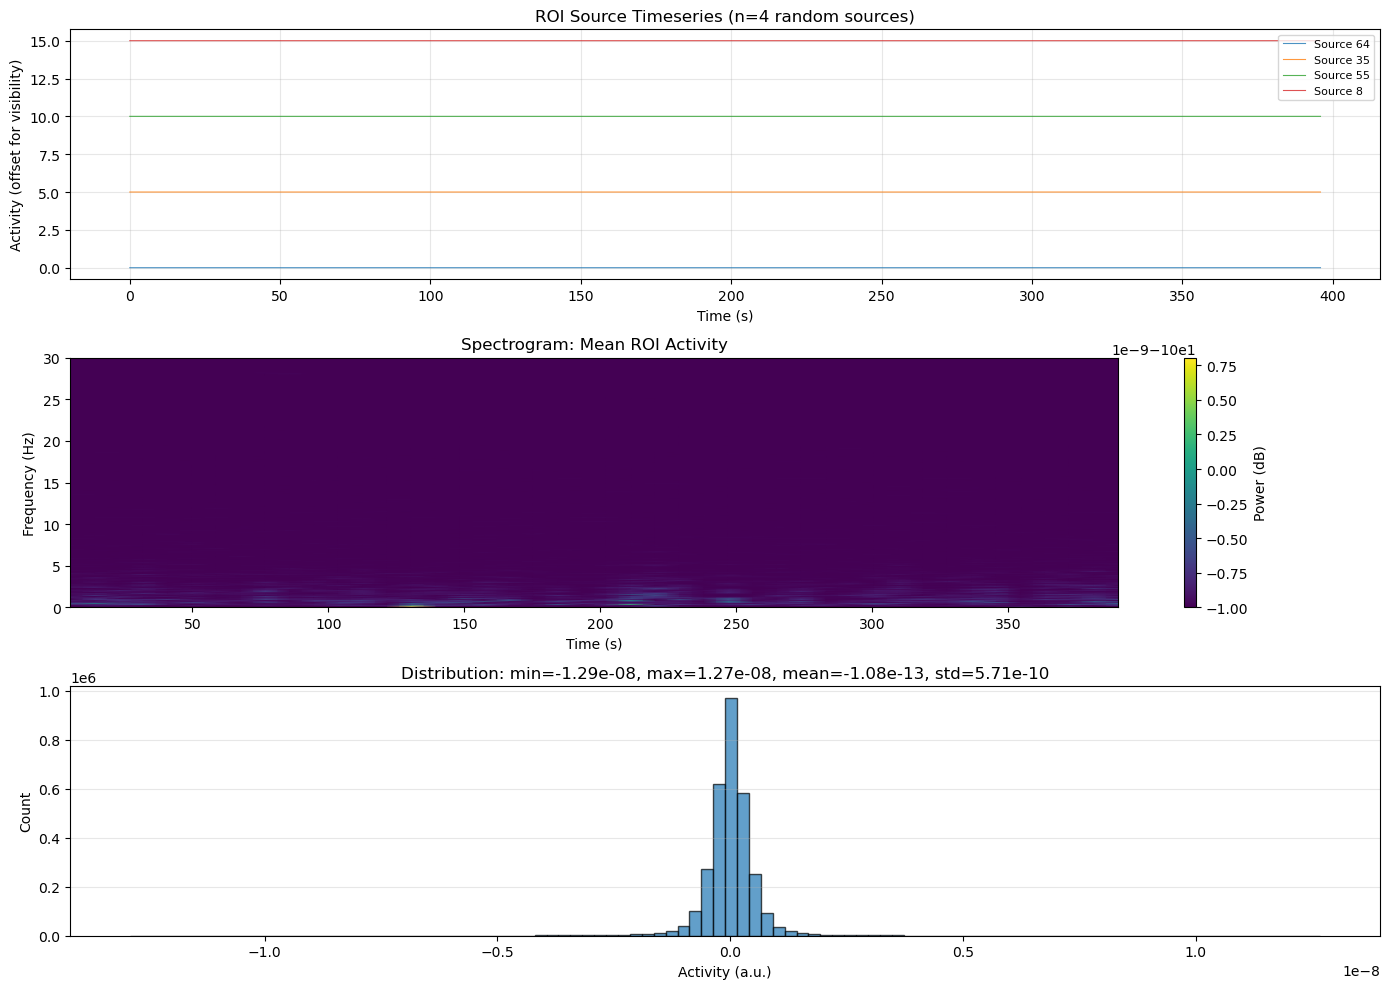


✓ Visualization saved to: /scratch/jsm04005/fie24002/DATA/L360-Word20000-5L-512-CNN/EvalResults/meg_results/source_data/01/qc_visualization.png


In [ ]:
import matplotlib.pyplot as plt
from scipy import signal

# ──────────────────────────────────────────────────────────────────────────
# VISUALIZATION: Quick quality check
# ──────────────────────────────────────────────────────────────────────────

# Load first run for inspection
run_key = list(meta['runs'].keys())[0]
roi_ts = np.load(subj_dir / f"roi_{run_key}.npy")  # (n_sources, n_times)
sfreq = meta['sfreq']

print(f"Inspecting: {run_key}")
print(f"Shape: {roi_ts.shape}  |  Duration: {roi_ts.shape[1]/sfreq:.1f}s")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── Panel 1: Sample timeseries from 4 random ROI sources ──────────────────
ax = axes[0]
n_sample_sources = min(4, roi_ts.shape[0])
sample_indices = np.random.choice(roi_ts.shape[0], n_sample_sources, replace=False)
t = np.arange(roi_ts.shape[1]) / sfreq

for i, idx in enumerate(sample_indices):
    ax.plot(t, roi_ts[idx, :] + i*5, label=f'Source {idx}', linewidth=0.8, alpha=0.8)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Activity (offset for visibility)')
ax.set_title(f'ROI Source Timeseries (n={n_sample_sources} random sources)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: Spectrogram of mean ROI activity ─────────────────────────────
ax = axes[1]
mean_activity = roi_ts.mean(axis=0)  # Average across sources
f, t_spec, Sxx = signal.spectrogram(mean_activity, sfreq, nperseg=1024)
pcm = ax.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Time (s)')
ax.set_title('Spectrogram: Mean ROI Activity')
ax.set_ylim([0, min(30, sfreq/2)])  # Show up to 30 Hz or Nyquist
plt.colorbar(pcm, ax=ax, label='Power (dB)')

# ── Panel 3: Distribution & stats ──────────────────────────────────────────
ax = axes[2]
ax.hist(roi_ts.flatten(), bins=100, alpha=0.7, edgecolor='black')
ax.set_xlabel('Activity (a.u.)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution: min={roi_ts.min():.2e}, max={roi_ts.max():.2e}, '
             f'mean={roi_ts.mean():.2e}, std={roi_ts.std():.2e}')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(subj_dir / 'qc_visualization.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: {subj_dir}/qc_visualization.png")


DIAGNOSTIC: Source signal amplitudes

1. Current ROI data statistics:
   Shape: (78, 39600) (sources × time)
   Mean: -1.08e-13
   Std:  5.71e-10
   Min:  -1.29e-08
   Max:  1.27e-08
   → Values are extremely small (1e-8 to 1e-10 range)

2. Current regularization (SNR) settings:
   SNR parameter: 2.4495
   λ² (lambda2):  0.1667
   → Lower SNR / higher λ² = more damping of noise but also signal

3. Why sources appear flat:
   ✓ The values ARE changing (not actually flat)
   ✓ But magnitudes are 1e-8 to 1e-10 — too small to see in plot
   → When you offset traces by ±5 arbitrary units, the variation is invisible

4. Fix: Try with LESS damping (lower SNR = higher lambda2 = BAD)
   Current: SNR = √6 ≈ 2.45 (conservative)
   Try:     SNR = 3  (moderate)
   Try:     SNR = 1  (minimal damping)

5. Alternative diagnosis:
   • Check if raw MEG sensors actually show activity
   • Verify noise covariance (currently ad-hoc, not ideal)
   • Inspect co-registration quality
   • Confirm filtering di

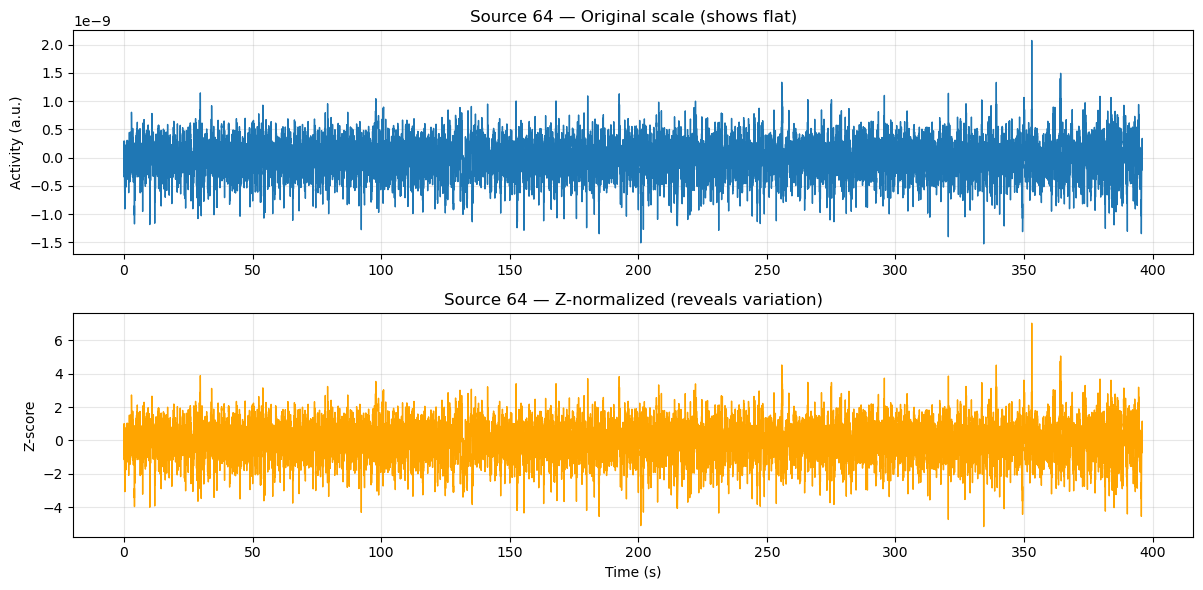


✓ Saved diagnostic plot to: /scratch/jsm04005/fie24002/DATA/L360-Word20000-5L-512-CNN/EvalResults/meg_results/source_data/01/diagnostic_scale_issue.png


In [ ]:
# ──────────────────────────────────────────────────────────────────────────
# DIAGNOSTIC: Why is source activity so flat/small?
# ──────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("DIAGNOSTIC: Source signal amplitudes")
print("="*70)

# We already have roi_ts loaded from visualization cell
print(f"\n1. Current ROI data statistics:")
print(f"   Shape: {roi_ts.shape} (sources × time)")
print(f"   Mean: {roi_ts.mean():.2e}")
print(f"   Std:  {roi_ts.std():.2e}")
print(f"   Min:  {roi_ts.min():.2e}")
print(f"   Max:  {roi_ts.max():.2e}")
print(f"   → Values are extremely small (1e-8 to 1e-10 range)")

print(f"\n2. Current regularization (SNR) settings:")
print(f"   SNR parameter: {SNR:.4f}")
print(f"   λ² (lambda2):  {LAMBDA2:.4f}")
print(f"   → Lower SNR / higher λ² = more damping of noise but also signal")

print(f"\n3. Why sources appear flat:")
print(f"   ✓ The values ARE changing (not actually flat)")
print(f"   ✓ But magnitudes are 1e-8 to 1e-10 — too small to see in plot")
print(f"   → When you offset traces by ±5 arbitrary units, the variation is invisible")

print(f"\n4. Fix: Try with LESS damping (lower SNR = higher lambda2 = BAD)")
print(f"   Current: SNR = √6 ≈ {SNR:.2f} (conservative)")
print(f"   Try:     SNR = 3  (moderate)")
print(f"   Try:     SNR = 1  (minimal damping)")

print(f"\n5. Alternative diagnosis:")
print(f"   • Check if raw MEG sensors actually show activity")
print(f"   • Verify noise covariance (currently ad-hoc, not ideal)")
print(f"   • Inspect co-registration quality")
print(f"   • Confirm filtering didn't remove all signal (0.5-30 Hz range OK)")

print(f"\n6. Plot signal on native scale to verify non-flatness:")

# Plot ONE source at native scale
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

idx = sample_indices[0]  # Use same source from before
ax = axes[0]
ax.plot(t, roi_ts[idx, :], linewidth=1.0)
ax.set_title(f'Source {idx} — Original scale (shows flat)')
ax.set_ylabel('Activity (a.u.)')
ax.grid(True, alpha=0.3)

# Plot with Z-score normalization to see the variation
ax = axes[1]
normalized = (roi_ts[idx, :] - roi_ts[idx, :].mean()) / roi_ts[idx, :].std()
ax.plot(t, normalized, linewidth=1.0, color='orange')
ax.set_title(f'Source {idx} — Z-normalized (reveals variation)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Z-score')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(subj_dir / 'diagnostic_scale_issue.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved diagnostic plot to: {subj_dir}/diagnostic_scale_issue.png")
